# Ranking

Ranking is the task of ordering a collection of items according to their relevance, importance, preference, or predicted usefulness.

Unlike classification, where a model predicts a class label, a ranking model determines the order in which items should appear.

For example, a search engine receives a query such as:

"best machine learning books"

There may be thousands of possible documents.

The goal of a ranking system is to place the most relevant documents at the top:

1. Highly relevant document
2. Relevant document
3. Moderately relevant document
4. Less relevant document
5. Irrelevant document

Ranking is an important problem in information retrieval, search engines, recommendation systems, advertising, and information filtering.

## 1. What is Ranking?

Suppose we have a query `q` and a set of candidate items:

$$
D = \{d_1, d_2, d_3, \dots, d_n\}
$$

A ranking model assigns a score to each item:

$$
s(q,d_i)
$$

The items are then sorted according to their scores.

If:

$$
s(q,d_3) > s(q,d_1) > s(q,d_2)
$$

then the ranking becomes:

$$
d_3 \rightarrow d_1 \rightarrow d_2
$$

Therefore, ranking can be viewed as a problem of learning how to order items correctly.

### Main idea

Higher score:

$$
\Rightarrow
$$

Higher position in the ranking.

## 2. Classification vs Ranking

Classification predicts a category.

For example:

- Spam
- Not Spam

Ranking predicts an ordering.

For example:

- Result A → Rank 1
- Result C → Rank 2
- Result B → Rank 3

### Classification

The model learns:

$$
X \rightarrow y
$$

where $y$ is a class label.

### Ranking

The model learns:

$$
(q,d) \rightarrow score
$$

and then sorts the items according to their scores.

### Important difference

Classification asks:

> Which class does this item belong to?

Ranking asks:

> In what order should these items appear?

## 3. Real-World Applications of Ranking

Ranking systems are used in many machine learning applications.

### Search Engines

Rank web pages according to their relevance to a search query.

### Recommendation Systems

Rank products, movies, songs, or videos according to predicted user interest.

### E-Commerce

Rank products according to relevance, popularity, price, or purchase probability.

### Advertising

Rank advertisements according to their predicted usefulness or probability of being clicked.

### Job Search

Rank job listings according to how well they match a candidate.

### Question Answering

Rank possible answers according to their relevance to a question.

### Content Recommendation

Rank articles, posts, or videos according to predicted user engagement.

## 4. Ranking Problem Formulation

Consider a query $q$ and candidate documents:

$$
D = \{d_1,d_2,\dots,d_n\}
$$

Each document has a relevance value:

$$
y_i
$$

For example:

| Document | Relevance |
|---|---:|
| $d_1$ | 3 |
| $d_2$ | 0 |
| $d_3$ | 2 |
| $d_4$ | 1 |

The ranking model predicts a score:

$$
\hat{s}_i = f(x_i)
$$

where:

- $x_i$ = features of the item
- $f$ = ranking model
- $\hat{s}_i$ = predicted ranking score

The items are sorted using:

$$
\hat{s}_1 > \hat{s}_2 > \dots > \hat{s}_n
$$

The goal is to make the predicted ordering as close as possible to the ideal ordering.

## 5. Types of Learning to Rank

Learning-to-Rank methods are commonly divided into three categories:

1. Pointwise methods
2. Pairwise methods
3. Listwise methods

These approaches differ in what the model considers as the training target.

## 6. Pointwise Ranking

In pointwise ranking, every item is considered independently.

The model predicts a relevance score for each item.

For example:

$$
x_i \rightarrow \hat{y}_i
$$

The model can treat ranking as a regression or classification problem.

For example:

$$
\hat{y}_i = f(x_i)
$$

Suppose the true relevance scores are:

$$
[3, 1, 0, 2]
$$

The model may predict:

$$
[2.8, 1.2, 0.4, 1.9]
$$

Sorting the predictions gives the ranking.

### Advantage

Pointwise methods are simple and can use standard regression or classification algorithms.

### Limitation

The model does not directly optimize relationships between items.

## 7. Pairwise Ranking

Pairwise ranking compares two items at a time.

Suppose:

$$
d_i > d_j
$$

This means document $d_i$ should be ranked higher than document $d_j$.

The model tries to learn:

$$
s(d_i) > s(d_j)
$$

Instead of predicting the exact relevance value, the model learns which item should win the pairwise comparison.

### Example

Suppose:

$$
d_1 > d_2
$$

and

$$
d_2 > d_3
$$

Then the desired ranking is:

$$
d_1 > d_2 > d_3
$$

Pairwise ranking is widely used in Learning-to-Rank algorithms.

## 8. Pairwise Ranking Objective

For a preferred item $i$ and a less preferred item $j$, we want:

$$
s_i > s_j
$$

Define the score difference:

$$
\Delta s = s_i - s_j
$$

A large positive value means the preferred item receives a higher score.

One common pairwise loss is the logistic loss:

$$
L = \log(1 + e^{-(s_i-s_j)})
$$

If:

$$
s_i \gg s_j
$$

then the loss becomes small.

If:

$$
s_i < s_j
$$

then the loss becomes large.

Therefore, the model is encouraged to assign larger scores to preferred items.

## 9. Listwise Ranking

Listwise methods consider the entire ranked list during training.

Instead of considering:

- one item
- or one pair of items

the model considers the complete list:

$$
[d_1,d_2,\dots,d_n]
$$

The objective is to produce a ranking that closely matches the ideal ordering.

Listwise methods are particularly useful when the quality of the entire ranking is important.

### Comparison

| Method | Training Unit |
|---|---|
| Pointwise | Individual item |
| Pairwise | Pair of items |
| Listwise | Entire list |

The three approaches represent different ways of formulating the ranking problem.

## 10. Learning to Rank

Learning to Rank (LTR) refers to machine learning methods that learn how to order items.

A ranking model receives features such as:

- Query-document similarity
- Text relevance
- Popularity
- User history
- Price
- Rating
- Click probability
- Freshness

The model combines these features to produce a ranking score.

Conceptually:

$$
x \rightarrow f(x) \rightarrow score
$$

The items are then sorted by score.

### General pipeline

Query/User

↓

Candidate Items

↓

Feature Extraction

↓

Ranking Model

↓

Ranking Scores

↓

Sort Items

↓

Final Ranked List

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 11. Creating a Simple Ranking Dataset

We will create a small dataset representing documents returned for a search query.

Each document will have several features:

- `text_relevance`
- `popularity`
- `quality`
- `freshness`

We will also define a relevance score.

The purpose of this example is to understand how ranking scores can be calculated from features.

In [2]:
data = pd.DataFrame({
    "document": [
        "Document A",
        "Document B",
        "Document C",
        "Document D",
        "Document E",
        "Document F",
        "Document G",
        "Document H"
    ],
    "text_relevance": [0.95, 0.70, 0.85, 0.40, 0.60, 0.90, 0.30, 0.75],
    "popularity": [0.80, 0.90, 0.60, 0.50, 0.70, 0.85, 0.40, 0.65],
    "quality": [0.90, 0.70, 0.85, 0.60, 0.75, 0.95, 0.50, 0.80],
    "freshness": [0.70, 0.60, 0.90, 0.80, 0.65, 0.75, 0.95, 0.85],
    "relevance": [3, 2, 3, 1, 2, 3, 0, 2]
})

data

,document,text_relevance,popularity,quality,freshness,relevance
0,Document A,0.95,0.80,0.90,0.70,3
1,Document B,0.70,0.90,0.70,0.60,2
2,Document C,0.85,0.60,0.85,0.90,3
3,Document D,0.40,0.50,0.60,0.80,1
4,Document E,0.60,0.70,0.75,0.65,2
5,Document F,0.90,0.85,0.95,0.75,3
6,Document G,0.30,0.40,0.50,0.95,0
7,Document H,0.75,0.65,0.80,0.85,2


## 12. Understanding the Ranking Features

Each document has four numerical features.

### Text Relevance

Measures how closely the document matches the query.

### Popularity

Measures how popular the document is.

### Quality

Represents the estimated quality of the document.

### Freshness

Measures how recently the content was created or updated.

A ranking system can combine these features to calculate an overall score.

## 13. A Simple Ranking Score

We can manually define a scoring function:

$$
Score =
w_1X_1 + w_2X_2 + w_3X_3 + w_4X_4
$$

where:

- $X_1$ = text relevance
- $X_2$ = popularity
- $X_3$ = quality
- $X_4$ = freshness

For example:

$$
Score =
0.5X_1 +
0.2X_2 +
0.2X_3 +
0.1X_4
$$

Text relevance receives the largest weight because relevance to the query is the most important factor in this simple example.

In [3]:
weights = {
    "text_relevance": 0.5,
    "popularity": 0.2,
    "quality": 0.2,
    "freshness": 0.1
}

data["ranking_score"] = (
    data["text_relevance"] * weights["text_relevance"]
    + data["popularity"] * weights["popularity"]
    + data["quality"] * weights["quality"]
    + data["freshness"] * weights["freshness"]
)

data

,document,text_relevance,popularity,quality,freshness,relevance,ranking_score
0,Document A,0.95,0.80,0.90,0.70,3,0.885
1,Document B,0.70,0.90,0.70,0.60,2,0.730
2,Document C,0.85,0.60,0.85,0.90,3,0.805
3,Document D,0.40,0.50,0.60,0.80,1,0.500
4,Document E,0.60,0.70,0.75,0.65,2,0.655
5,Document F,0.90,0.85,0.95,0.75,3,0.885
6,Document G,0.30,0.40,0.50,0.95,0,0.425
7,Document H,0.75,0.65,0.80,0.85,2,0.750


## 14. Sorting Items by Ranking Score

Once every item has a predicted score, we sort the items in descending order.

The item with the highest score receives rank 1.

The item with the second-highest score receives rank 2.

And so on.

Therefore:

$$
Rank(d_i) =
\text{position of } d_i \text{ after sorting by score}
$$

In [4]:
ranking = data.sort_values(
    by="ranking_score",
    ascending=False
).reset_index(drop=True)

ranking["rank"] = np.arange(1, len(ranking) + 1)

ranking[
    ["rank", "document", "ranking_score", "relevance"]
]

,rank,document,ranking_score,relevance
0,1,Document A,0.885,3
1,2,Document F,0.885,3
2,3,Document C,0.805,3
3,4,Document H,0.750,2
4,5,Document B,0.730,2
5,6,Document E,0.655,2
6,7,Document D,0.500,1
7,8,Document G,0.425,0


## 15. Visualizing the Ranking

A bar chart makes the ranking scores easier to understand.

Higher bars represent higher predicted ranking scores.

The documents are displayed in their predicted ranking order.

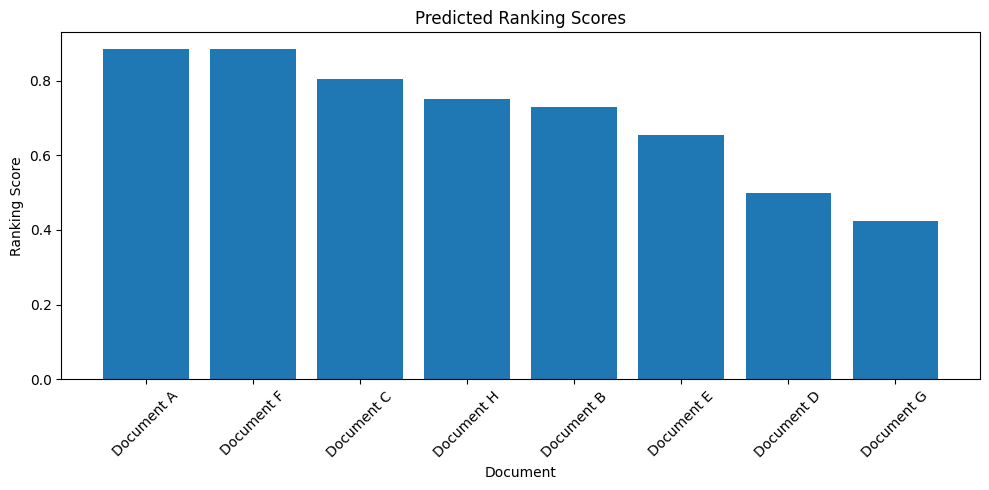

In [5]:
plt.figure(figsize=(10, 5))

plt.bar(
    ranking["document"],
    ranking["ranking_score"]
)

plt.xlabel("Document")
plt.ylabel("Ranking Score")
plt.title("Predicted Ranking Scores")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 16. Ranking with Logistic Regression

Ranking can also be formulated using classification models.

Suppose we define:

- Relevant = 1
- Not Relevant = 0

A logistic regression model can estimate:

$$
P(y=1|x)
$$

This probability can be interpreted as a relevance score.

The items are then sorted according to the predicted probability.

Therefore:

$$
x \rightarrow P(y=1|x) \rightarrow ranking
$$

This is a simple example of a pointwise ranking approach.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [7]:
features = [
    "text_relevance",
    "popularity",
    "quality",
    "freshness"
]

X = data[features]

y = (data["relevance"] >= 2).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalti

## 17. Predicting Relevance Scores

For ranking, we are interested in the model's predicted probability.

For each item:

$$
score = P(y=1|x)
$$

A higher probability means that the model considers the item more likely to be relevant.

We can sort the items according to this probability.

In [8]:
data["predicted_relevance_probability"] = model.predict_proba(
    data[features]
)[:, 1]

ranked_predictions = data.sort_values(
    by="predicted_relevance_probability",
    ascending=False
).reset_index(drop=True)

ranked_predictions["rank"] = np.arange(
    1,
    len(ranked_predictions) + 1
)

ranked_predictions[
    [
        "rank",
        "document",
        "predicted_relevance_probability",
        "relevance"
    ]
]

,rank,document,predicted_relevance_probability,relevance
0,1,Document F,0.991132,3
1,2,Document A,0.988496,3
2,3,Document B,0.948102,2
3,4,Document C,0.935720,3
4,5,Document H,0.909096,2
5,6,Document E,0.880225,2
6,7,Document D,0.338525,1
7,8,Document G,0.092970,0


## 18. Ranking Evaluation

A ranking model should not only be evaluated by classification accuracy.

The order of the results matters.

For example, consider:

### Ranking A

$$
[3, 2, 1, 0]
$$

### Ranking B

$$
[0, 1, 2, 3]
$$

Both contain the same relevance values.

However, Ranking A is much better because the most relevant items appear at the top.

Therefore, ranking requires specialized evaluation metrics.

## 19. Precision@K

Precision@K measures how many of the top $K$ results are relevant.

$$
Precision@K =
\frac{\text{Relevant items in top }K}{K}
$$

For example, suppose the top 5 results are:

$$
[1,1,0,1,0]
$$

There are 3 relevant items.

Therefore:

$$
Precision@5 = \frac{3}{5}=0.6
$$

Precision@K focuses on the quality of the first $K$ results.

In [9]:
def precision_at_k(relevance, k):
    relevance = np.asarray(relevance)[:k]
    return np.sum(relevance) / k

In [10]:
example_relevance = [1, 1, 0, 1, 0]

precision_at_5 = precision_at_k(
    example_relevance,
    5
)

print("Precision@5:", precision_at_5)

Precision@5: 0.6


## 20. Recall@K

Recall@K measures how many of all relevant items were retrieved within the top $K$ positions.

$$
Recall@K =
\frac{\text{Relevant items in top }K}
{\text{Total relevant items}}
$$

For example, suppose there are 4 relevant items in total.

If the top 5 results contain 3 relevant items:

$$
Recall@5 = \frac{3}{4}=0.75
$$

Precision@K focuses on the proportion of relevant results in the top $K$.

Recall@K focuses on how many relevant items were successfully retrieved.

In [11]:
def recall_at_k(relevance, total_relevant, k):
    relevance = np.asarray(relevance)[:k]
    
    if total_relevant == 0:
        return 0.0
    
    return np.sum(relevance) / total_relevant

In [12]:
retrieved_relevance = [1, 0, 1, 1, 0, 0, 1]
total_relevant_docs = 5
k_val = 3

# Function call
recall = recall_at_k(retrieved_relevance, total_relevant=total_relevant_docs, k=k_val)
print(f"Recall@{k_val}: {recall:.2f}")

Recall@3: 0.40


## 21. Mean Reciprocal Rank (MRR)

Mean Reciprocal Rank measures how high the first relevant result appears.

For a single query:

$$
RR = \frac{1}{rank\ of\ first\ relevant\ result}
$$

For multiple queries:

$$
MRR =
\frac{1}{N}
\sum_{i=1}^{N}
\frac{1}{rank_i}
$$

where $rank_i$ is the position of the first relevant result for query $i$.

### Example

If the first relevant result appears at rank 2:

$$
RR = \frac{1}{2}=0.5
$$

If it appears at rank 1:

$$
RR = 1
$$

Therefore, MRR rewards systems that place a relevant result very near the top.

In [13]:
def reciprocal_rank(relevance):
    for rank, value in enumerate(relevance, start=1):
        if value > 0:
            return 1 / rank
    
    return 0.0

In [14]:
example_relevance = [0, 1, 0, 1, 0]

rr = reciprocal_rank(example_relevance)

print("Reciprocal Rank:", rr)

Reciprocal Rank: 0.5


## 22. Discounted Cumulative Gain (DCG)

DCG evaluates the usefulness of a ranked list while giving more importance to items appearing near the top.

A common formulation is:

$$
DCG@K =
\sum_{i=1}^{K}
\frac{2^{rel_i}-1}
{\log_2(i+1)}
$$

where:

- $rel_i$ = relevance of the item at position $i$
- $i$ = ranking position

The logarithmic denominator discounts lower-ranked results.

Therefore, a highly relevant result at rank 1 contributes more than the same result at rank 5.

In [15]:
def dcg_at_k(relevance, k):
    relevance = np.asarray(relevance)[:k]
    
    if len(relevance) == 0:
        return 0.0
    
    positions = np.arange(1, len(relevance) + 1)
    
    gains = 2 ** relevance - 1
    discounts = np.log2(positions + 1)
    
    return np.sum(gains / discounts)

In [16]:
relevance = [3, 2, 1, 0]

dcg = dcg_at_k(
    relevance,
    4
)

print("DCG@4:", dcg)

DCG@4: 9.392789260714373


## 23. Normalized Discounted Cumulative Gain (NDCG)

DCG depends on the relevance values and the length of the ranking.

To normalize it, we compare the predicted ranking with the ideal ranking.

$$
NDCG@K =
\frac{DCG@K}{IDCG@K}
$$

where:

- DCG@K = DCG of the predicted ranking
- IDCG@K = maximum possible DCG for the ideal ranking

The value usually lies between:

$$
0 \leq NDCG@K \leq 1
$$

A value closer to 1 means that the ranking is closer to the ideal ranking.

NDCG is one of the most important metrics for evaluating ranking systems.

In [17]:
def ndcg_at_k(relevance, k):
    relevance = np.asarray(relevance)[:k]
    
    actual_dcg = dcg_at_k(relevance, k)
    
    ideal_relevance = np.sort(relevance)[::-1]
    ideal_dcg = dcg_at_k(ideal_relevance, k)
    
    if ideal_dcg == 0:
        return 0.0
    
    return actual_dcg / ideal_dcg

In [18]:
ranking_a = [3, 2, 1, 0]
ranking_b = [0, 1, 2, 3]

print("NDCG Ranking A:", ndcg_at_k(ranking_a, 4))
print("NDCG Ranking B:", ndcg_at_k(ranking_b, 4))

NDCG Ranking A: 1.0
NDCG Ranking B: 0.547831481922746


## 24. Comparing Ranking Metrics

Different metrics measure different aspects of ranking quality.

| Metric | Main Purpose |
|---|---|
| Precision@K | Relevant proportion in top K |
| Recall@K | Relevant items retrieved in top K |
| MRR | Position of first relevant result |
| DCG@K | Ranking quality with position discount |
| NDCG@K | Normalized ranking quality |

There is no single metric that is best for every ranking problem.

The appropriate metric depends on the application's objective.

## 25. Practical Ranking Example

Let's create two possible rankings for the same query.

The relevance scale is:

- 3 = Highly relevant
- 2 = Relevant
- 1 = Slightly relevant
- 0 = Not relevant

We will compare the quality of two ranking systems.

In [19]:
system_a = [3, 3, 2, 1, 0]
system_b = [0, 2, 3, 1, 3]

metrics = pd.DataFrame({
    "Metric": [
        "NDCG@5",
        "DCG@5"
    ],
    "System A": [
        ndcg_at_k(system_a, 5),
        dcg_at_k(system_a, 5)
    ],
    "System B": [
        ndcg_at_k(system_b, 5),
        dcg_at_k(system_b, 5)
    ]
})

metrics

,Metric,System A,System B
0,NDCG@5,1.000000,0.639194
1,DCG@5,13.347185,8.531435


## 26. Visualizing Relevance by Rank

The following visualization shows the relevance value at each ranking position.

A good ranking should generally place highly relevant items toward the top.

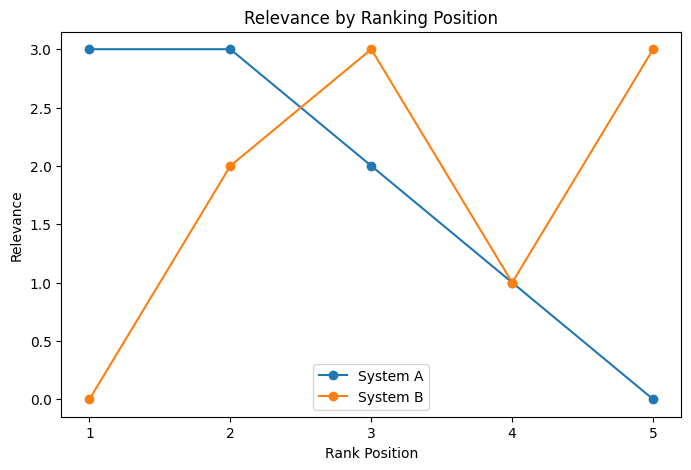

In [20]:
positions = np.arange(1, 6)

plt.figure(figsize=(8, 5))

plt.plot(
    positions,
    system_a,
    marker="o",
    label="System A"
)

plt.plot(
    positions,
    system_b,
    marker="o",
    label="System B"
)

plt.xlabel("Rank Position")
plt.ylabel("Relevance")
plt.title("Relevance by Ranking Position")

plt.xticks(positions)
plt.legend()

plt.show()

## 27. Complete Ranking Pipeline

A practical ranking system usually follows these steps:

### Step 1 — Define the Query

The user provides a query or preference.

### Step 2 — Retrieve Candidates

A set of potentially relevant items is collected.

### Step 3 — Extract Features

Features are calculated for every candidate.

### Step 4 — Predict Ranking Scores

A machine learning model assigns a score to each candidate.

### Step 5 — Sort Candidates

Candidates are sorted from highest score to lowest score.

### Step 6 — Evaluate

The ranking is evaluated using metrics such as:

- Precision@K
- Recall@K
- MRR
- NDCG

### Overall Pipeline

$$
Query
\rightarrow
Candidates
\rightarrow
Features
\rightarrow
Ranking\ Model
\rightarrow
Scores
\rightarrow
Sorting
\rightarrow
Ranked\ Results
$$

## 28. Important Ranking Concepts

### Relevance

How useful an item is for a particular query or user.

### Ranking Score

A numerical value produced by a ranking model.

### Rank

The position of an item in the final ordered list.

### Top-K

The first $K$ results of a ranking.

### Pairwise Preference

A relationship indicating that one item should appear above another.

### Ideal Ranking

The ranking obtained when items are ordered perfectly according to their true relevance.

## 29. Pointwise vs Pairwise vs Listwise

### Pointwise

Treat each item independently.

$$
x_i \rightarrow y_i
$$

### Pairwise

Learn which of two items should be ranked higher.

$$
d_i > d_j
$$

### Listwise

Optimize the ordering of the entire list.

$$
[d_1,d_2,\dots,d_n]
$$

### Key Idea

The main difference is the unit of learning:

$$
Individual
\rightarrow
Pair
\rightarrow
List
$$

## 30. Advantages of Ranking Models

Ranking models are useful because they:

- Prioritize the most useful results.
- Improve search result ordering.
- Personalize recommendations.
- Combine many features.
- Optimize the ordering of information.
- Support large-scale information retrieval systems.

Ranking is especially important when users interact primarily with the first few results.

## 31. Limitations and Challenges

Ranking systems also have several challenges.

### Relevance Is Difficult to Define

Different users may consider different items relevant.

### Position Bias

Users are more likely to click items near the top.

### Feedback Bias

Historical clicks may not perfectly represent true relevance.

### Changing User Preferences

User interests can change over time.

### Large Candidate Sets

Search and recommendation systems may need to rank millions of candidates.

### Evaluation Difficulty

Offline ranking metrics may not always perfectly represent real-world user satisfaction.

## 32. Summary

Ranking is the problem of ordering items according to their predicted relevance, usefulness, or preference.

The basic idea is:

$$
Features
\rightarrow
Ranking\ Model
\rightarrow
Score
\rightarrow
Sort
$$

The major Learning-to-Rank approaches are:

1. Pointwise
2. Pairwise
3. Listwise

Important ranking metrics include:

- Precision@K
- Recall@K
- MRR
- DCG
- NDCG

The key difference between classification and ranking is that ranking cares not only about the predicted values, but also about their **relative order**.

A good ranking system places the most useful items near the top of the result list.

## Final Takeaway

Ranking is fundamental to modern machine learning systems.

Whenever a system needs to decide:

> "Which item should appear first?"

ranking becomes important.

Search engines, recommendation systems, e-commerce platforms, advertising systems, job portals, and many other applications use ranking techniques to order information.

The central objective is:

$$
\boxed{\text{Put the most relevant items at the top}}
$$